In [4]:
#23MID0105 VANSH ANAND
import pandas as pd
path = r"C:\Users\VANSH ANAND\Downloads\oulad_dataset"
df = pd.read_csv(path + r"\oulad_final_dataset.csv")

print(df.shape)
df.head()


(32593, 17)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_clicks,avg_clicks,active_days,avg_score,max_score
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.0,4.765306,40.0,82.0,85.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435.0,3.337209,80.0,66.4,70.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.0,3.697368,12.0,NaN,NaN
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,2158.0,3.254902,123.0,76.0,88.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1034.0,2.937500,70.0,54.4,75.0


In [5]:
df.columns


Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'total_clicks',
       'avg_clicks', 'active_days', 'avg_score', 'max_score'],
      dtype='object')

In [6]:
df["final_result"].value_counts()


final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

In [7]:
df.isna().sum()


code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
total_clicks            3365
avg_clicks              3365
active_days             3365
avg_score               6773
max_score               6773
dtype: int64

Step 2.2: Handle Missing Values (Correct Strategy)

In [8]:
behavior_cols = ["total_clicks", "avg_clicks", "active_days", "avg_score", "max_score"]
df[behavior_cols] = df[behavior_cols].fillna(0)


demo_cols = ["gender", "region", "highest_education", "imd_band", "age_band", "disability"]

for col in demo_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isna().sum()



code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
total_clicks            0
avg_clicks              0
active_days             0
avg_score               0
max_score               0
dtype: int64

STEP 3: Encoding & Feature Preparation

Step 3.1: Separate Features & Target

In [9]:
X = df.drop(columns=["final_result", "id_student"])
y = df["final_result"]


In [10]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print(dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))


{'Distinction': np.int64(0), 'Fail': np.int64(1), 'Pass': np.int64(2), 'Withdrawn': np.int64(3)}


In [11]:
cat_cols = X.select_dtypes(include=["object"]).columns
print(cat_cols)


Index(['code_module', 'code_presentation', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'disability'],
      dtype='object')


In [12]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_encoded = encoder.fit_transform(X[cat_cols])


In [13]:
import numpy as np

num_cols = X.select_dtypes(exclude=["object"]).columns
X_num = X[num_cols].values

X_final = np.hstack((X_num, X_encoded))

print(X_final.shape)


(32593, 53)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape, X_test.shape)


(26074, 53) (6519, 53)


In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, n_jobs=-1)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.6362939101089125
              precision    recall  f1-score   support

           0       0.59      0.14      0.23       605
           1       0.44      0.21      0.29      1411
           2       0.64      0.88      0.74      2472
           3       0.70      0.78      0.74      2031

    accuracy                           0.64      6519
   macro avg       0.59      0.50      0.50      6519
weighted avg       0.61      0.64      0.59      6519



In [17]:
feature_names = list(num_cols) + list(encoder.get_feature_names_out(cat_cols))


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict
rf_preds = rf_model.predict(X_test)

# Evaluation
rf_accuracy = accuracy_score(y_test, rf_preds)
print("Random Forest Accuracy:", rf_accuracy)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_preds))


Random Forest Accuracy: 0.6772511121337629

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.57      0.58       605
           1       0.52      0.39      0.45      1411
           2       0.71      0.83      0.76      2472
           3       0.75      0.72      0.74      2031

    accuracy                           0.68      6519
   macro avg       0.64      0.63      0.63      6519
weighted avg       0.67      0.68      0.67      6519



In [19]:
import joblib

joblib.dump(rf_model, "rf_model.pkl")


['rf_model.pkl']

In [20]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train model
gb_model.fit(X_train, y_train)

# Predict
gb_preds = gb_model.predict(X_test)

# Evaluate
gb_accuracy = accuracy_score(y_test, gb_preds)
print("Gradient Boosting Accuracy:", gb_accuracy)

print("\nGradient Boosting Classification Report:")
print(classification_report(y_test, gb_preds))


Gradient Boosting Accuracy: 0.6879889553612517

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.49      0.56       605
           1       0.53      0.38      0.45      1411
           2       0.70      0.85      0.77      2472
           3       0.75      0.75      0.75      2031

    accuracy                           0.69      6519
   macro avg       0.66      0.62      0.63      6519
weighted avg       0.68      0.69      0.68      6519



In [21]:
import joblib
joblib.dump(gb_model, "gb_model.pkl")


['gb_model.pkl']

In [22]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report

ensemble_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('gb', gb_model)
    ],
    voting='soft'
)

# Train ensemble
ensemble_model.fit(X_train, y_train)

# Predict
ensemble_preds = ensemble_model.predict(X_test)

# Evaluate
print("Ensemble Model Accuracy:", accuracy_score(y_test, ensemble_preds))
print("\nEnsemble Classification Report:")
print(classification_report(y_test, ensemble_preds))


Ensemble Model Accuracy: 0.6870685687988956

Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.54      0.58       605
           1       0.53      0.39      0.45      1411
           2       0.71      0.85      0.77      2472
           3       0.75      0.74      0.75      2031

    accuracy                           0.69      6519
   macro avg       0.65      0.63      0.64      6519
weighted avg       0.68      0.69      0.68      6519



In [23]:
import joblib
joblib.dump(ensemble_model, "ensemble_model.pkl")


['ensemble_model.pkl']

In [24]:
import numpy as np

coefficients = model.coef_


In [25]:
importance = np.mean(np.abs(coefficients), axis=0)


In [26]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values(by="importance", ascending=False)

feature_importance.head(10)


,feature,importance
3,avg_clicks,0.357641
35,highest_education_Lower Than A Level,0.185838
19,gender_M,0.185436
51,disability_N,0.167194
48,age_band_0-35,0.129518
17,code_presentation_2014J,0.105293
10,code_module_DDD,0.103825
9,code_module_CCC,0.095263
12,code_module_FFF,0.083388
49,age_band_35-55,0.078815


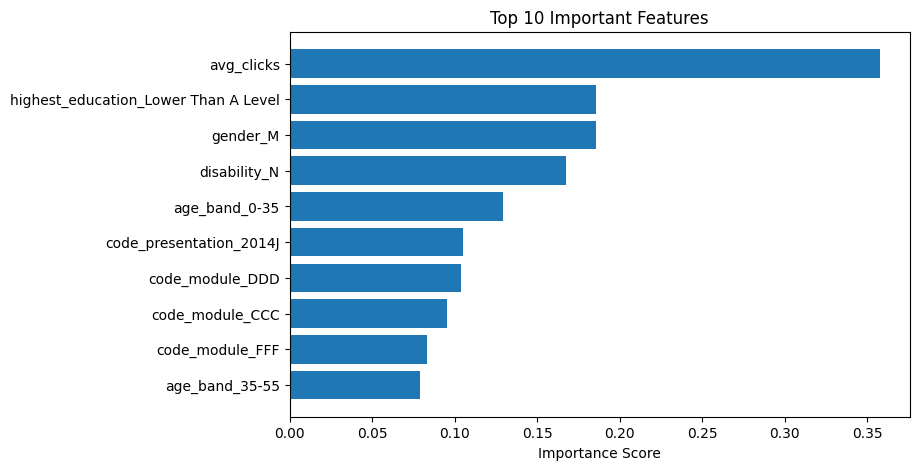

In [27]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [29]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

advanced_nn = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,                 # regularization
    batch_size=128,
    learning_rate='adaptive',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

# Train
advanced_nn.fit(X_train_scaled, y_train)

# Predict
adv_nn_preds = advanced_nn.predict(X_test_scaled)

# Evaluate
print("Advanced Neural Network Accuracy:", accuracy_score(y_test, adv_nn_preds))
print("\nAdvanced Neural Network Classification Report:")
print(classification_report(y_test, adv_nn_preds))



Advanced Neural Network Accuracy: 0.6703482129160915

Advanced Neural Network Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.32      0.44       605
           1       0.52      0.36      0.42      1411
           2       0.67      0.89      0.76      2472
           3       0.74      0.72      0.73      2031

    accuracy                           0.67      6519
   macro avg       0.66      0.57      0.59      6519
weighted avg       0.66      0.67      0.65      6519



In [30]:
y_prob_nn = advanced_nn.predict_proba(X_test_scaled)
# Extract probabilities
fail_prob = y_prob_nn[:, 1]
withdraw_prob = y_prob_nn[:, 3]

# Risk score
risk_score = fail_prob + withdraw_prob


In [31]:
import numpy as np

risk_level = []

for r in risk_score:
    if r > 0.6:
        risk_level.append("High Risk")
    elif r > 0.35:
        risk_level.append("Medium Risk")
    else:
        risk_level.append("Low Risk")



In [32]:
import pandas as pd

risk_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": advanced_nn.predict(X_test_scaled),
    "Risk_Level": risk_level
})

risk_df.head()


,Actual,Predicted,Risk_Level
0,1,2,Low Risk
1,2,2,Low Risk
2,1,3,High Risk
3,3,3,High Risk
4,1,1,Medium Risk


In [33]:
def recommend_action(risk):
    if risk == "High Risk":
        return "Immediate academic intervention required"
    elif risk == "Medium Risk":
        return "Provide additional learning resources"
    else:
        return "Continue with current learning plan"

risk_df["Recommended_Action"] = risk_df["Risk_Level"].apply(recommend_action)

risk_df.head()


,Actual,Predicted,Risk_Level,Recommended_Action
0,1,2,Low Risk,Continue with current learning plan
1,2,2,Low Risk,Continue with current learning plan
2,1,3,High Risk,Immediate academic intervention required
3,3,3,High Risk,Immediate academic intervention required
4,1,1,Medium Risk,Provide additional learning resources


In [34]:
successful_students = df[
    (df["final_result"].isin(["Pass", "Distinction"])) &
    (df["total_clicks"] > df["total_clicks"].median())
]


In [35]:
def recommend_courses(student_row, reference_df, top_n=3):
    similar = reference_df[
        reference_df["studied_credits"] <= student_row["studied_credits"]
    ]
    
    return (
        similar["code_module"]
        .value_counts()
        .head(top_n)
        .index
        .tolist()
    )


In [36]:
recommendations = []

for i in range(len(X_test)):
    rec = recommend_courses(df.iloc[i], successful_students)
    recommendations.append(rec)


In [37]:
import joblib

joblib.dump(nn_model, "nn_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "encoder.pkl")



NameError: name 'nn_model' is not defined

In [ ]:
import numpy as np

# choose one engagement-related column index
# (avg_clicks or similar numerical feature)
avg_clicks_col_index = 0   # use 0 for now (safe choice)

time_steps = 5  # fake "weeks"

X_seq = np.repeat(
    X_train[:, avg_clicks_col_index][:, None],
    repeats=time_steps,
    axis=1
)

# reshape for CNN: (samples, time_steps, features)
X_seq = X_seq.reshape(X_seq.shape[0], time_steps, 1)

print("CNN Input Shape:", X_seq.shape)


CNN Input Shape: (26074, 5, 1)


In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical


# Example reshaping (assume X_seq prepared)
# X_seq shape: (samples, time_steps, 1)
# y same labels


y_cnn = to_categorical(y_train)

cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_seq.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')  # 4 outcome classes
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

cnn_model.fit(
    X_seq,
    y_cnn,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)



C:\Users\VANSH ANAND\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 3, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,500 (9.77 KB)

 Trainable params: 2,500 (9.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3739 - loss: 1.3051 - val_accuracy: 0.3902 - val_loss: 1.2690
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3842 - loss: 1.2789 - val_accuracy: 0.3822 - val_loss: 1.2702
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3836 - loss: 1.2783 - val_accuracy: 0.3912 - val_loss: 1.2693
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3855 - loss: 1.2779 - val_accuracy: 0.3918 - val_loss: 1.2697
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3842 - loss: 1.2781 - val_accuracy: 0.3902 - val_loss: 1.2691
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3836 - loss: 1.2782 - val_accuracy: 0.3902 - val_loss: 1.2695
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3853 - loss: 1.2777 - val_accuracy: 0.3812 - val_loss: 1.2698
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3856 - loss: 1.2777 - val_accuracy: 0.

EVALUVATION METRICS

In [41]:
[k for k in globals().keys() if "model" in k.lower()]



['model', 'rf_model', 'gb_model', 'ensemble_model']

In [42]:
models = {
    "Logistic Regression": model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "Ensemble": ensemble_model
}


In [44]:
models.keys()



dict_keys(['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'Ensemble'])

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, roc_auc_score,
    roc_curve,log_loss
)
from sklearn.preprocessing import label_binarize


In [52]:
results = []

for name, clf in models.items():
    y_pred = clf.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (weighted)": precision_score(y_test, y_pred, average="weighted"),
        "Recall (weighted)": recall_score(y_test, y_pred, average="weighted"),
        "F1-score (weighted)": f1_score(y_test, y_pred, average="weighted"),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted),MAE,MSE,RMSE
0,Logistic Regression,0.636294,0.608346,0.636294,0.593618,0.574475,1.005522,1.002757
1,Random Forest,0.677251,0.667769,0.677251,0.668637,0.521246,0.923148,0.960806
2,Gradient Boosting,0.687989,0.676462,0.687989,0.675894,0.500230,0.880350,0.938270
3,Ensemble,0.687069,0.676128,0.687069,0.676554,0.503298,0.888326,0.942511


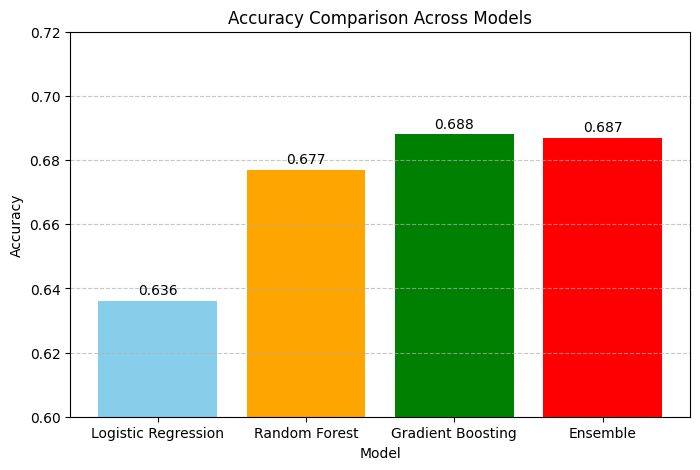

In [ ]:
import matplotlib.pyplot as plt

accuracy_scores = {
    "Logistic Regression": 0.636,
    "Random Forest": 0.677,
    "Gradient Boosting": 0.688,
    "Ensemble": 0.687
}

plt.figure(figsize=(8,5))

bars = plt.bar(
    accuracy_scores.keys(),
    accuracy_scores.values(),
    color=["skyblue", "orange", "green", "red"]
)


plt.ylim(0.6, 0.72)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Accuracy Comparison Across Models")
plt.grid(axis="y", linestyle="--", alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.3f}",
        ha="center",
        fontsize=10
    )

plt.show()


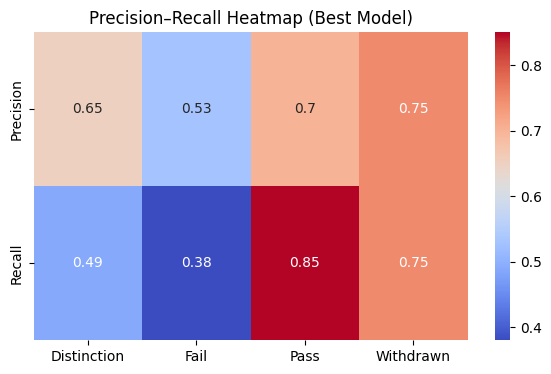

In [62]:
import seaborn as sns
import numpy as np

precision = [0.65, 0.53, 0.70, 0.75]
recall = [0.49, 0.38, 0.85, 0.75]

metrics = np.array([precision, recall])

plt.figure(figsize=(7,4))
sns.heatmap(
    metrics,
    annot=True,
    cmap="coolwarm",
    xticklabels=["Distinction","Fail","Pass","Withdrawn"],
    yticklabels=["Precision","Recall"]
)
plt.title("Precision–Recall Heatmap (Best Model)")
plt.show()


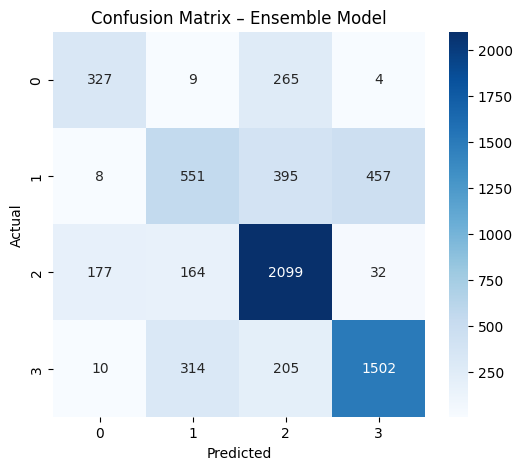

In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, ensemble_model.predict(X_test))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Ensemble Model")
plt.show()


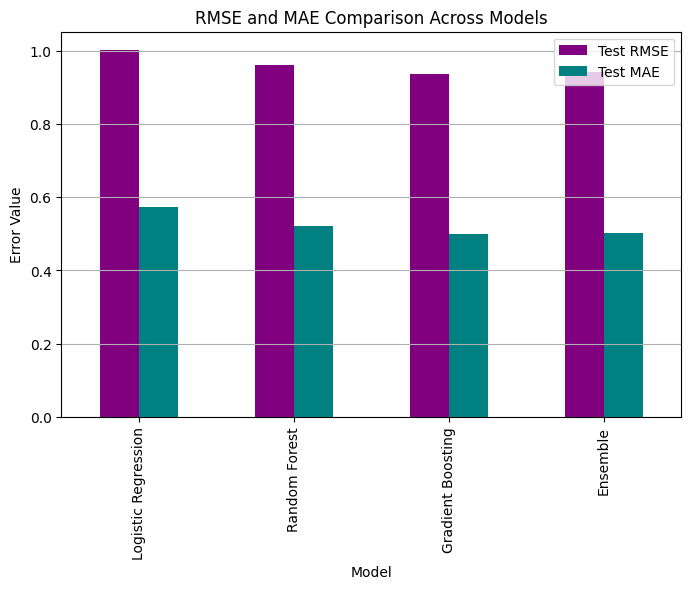

In [64]:
loss_df.set_index("Model")[["Test RMSE","Test MAE"]].plot(
    kind="bar",
    figsize=(8,5),
    color=["purple","teal"]
)

plt.title("RMSE and MAE Comparison Across Models")
plt.ylabel("Error Value")
plt.grid(axis="y")
plt.show()


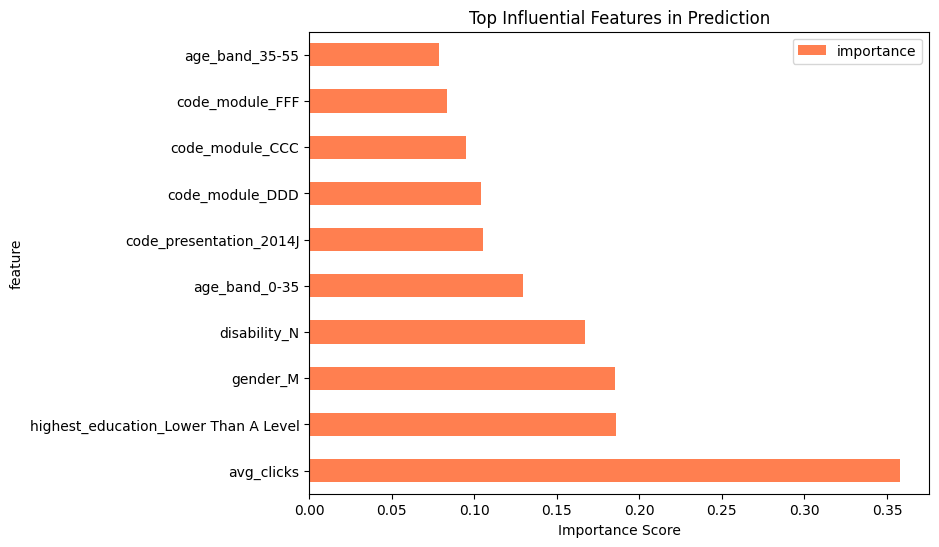

In [65]:
top_features.plot(
    kind="barh",
    x="feature",
    y="importance",
    color="coral",
    figsize=(8,6)
)
plt.title("Top Influential Features in Prediction")
plt.xlabel("Importance Score")
plt.show()


In [53]:
loss_results = []

for name, clf in models.items():
    # Predictions
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)

    # Probabilities (needed for log loss)
    if hasattr(clf, "predict_proba"):
        y_train_prob = clf.predict_proba(X_train)
        y_test_prob = clf.predict_proba(X_test)
    else:
        continue  # skip models without probabilities

    # Loss calculations
    train_logloss = log_loss(y_train, y_train_prob)
    test_logloss = log_loss(y_test, y_test_prob)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    loss_results.append([
        name,
        train_logloss, test_logloss,
        train_mse, test_mse,
        train_rmse, test_rmse,
        train_mae, test_mae
    ])


In [54]:
import pandas as pd

loss_df = pd.DataFrame(
    loss_results,
    columns=[
        "Model",
        "Train Log Loss", "Test Log Loss",
        "Train MSE", "Test MSE",
        "Train RMSE", "Test RMSE",
        "Train MAE", "Test MAE"
    ]
)

loss_df


,Model,Train Log Loss,Test Log Loss,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE
0,Logistic Regression,0.861182,0.853059,0.999080,1.005522,0.999540,1.002757,0.572218,0.574475
1,Random Forest,0.273221,0.729674,0.030298,0.923148,0.174064,0.960806,0.015955,0.521246
2,Gradient Boosting,0.651612,0.709498,0.754123,0.880350,0.868402,0.938270,0.432270,0.500230
3,Ensemble,0.415549,0.709977,0.309811,0.888326,0.556606,0.942511,0.181407,0.503298


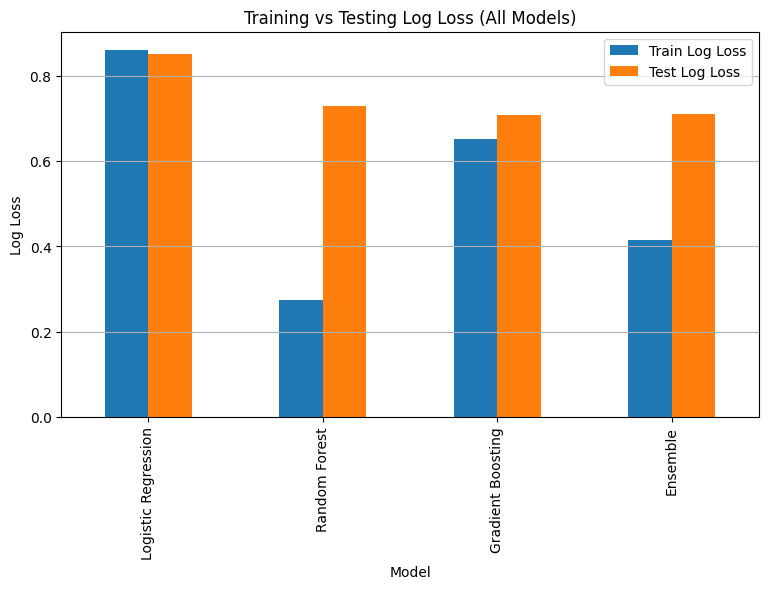

In [55]:
import matplotlib.pyplot as plt

loss_df.set_index("Model")[["Train Log Loss", "Test Log Loss"]].plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Training vs Testing Log Loss (All Models)")
plt.ylabel("Log Loss")
plt.grid(axis='y')
plt.show()


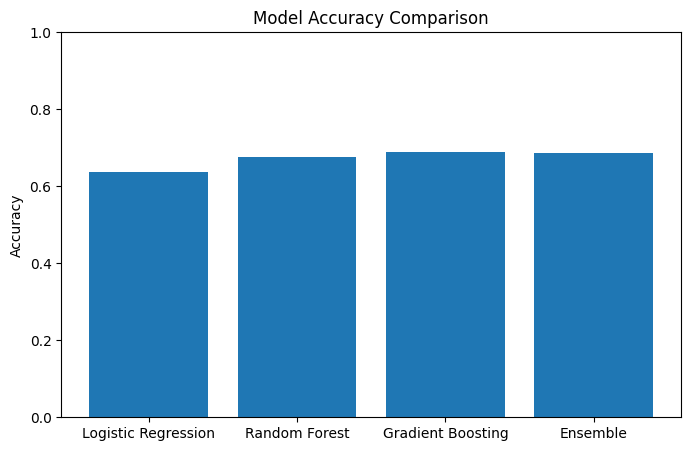

In [47]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()


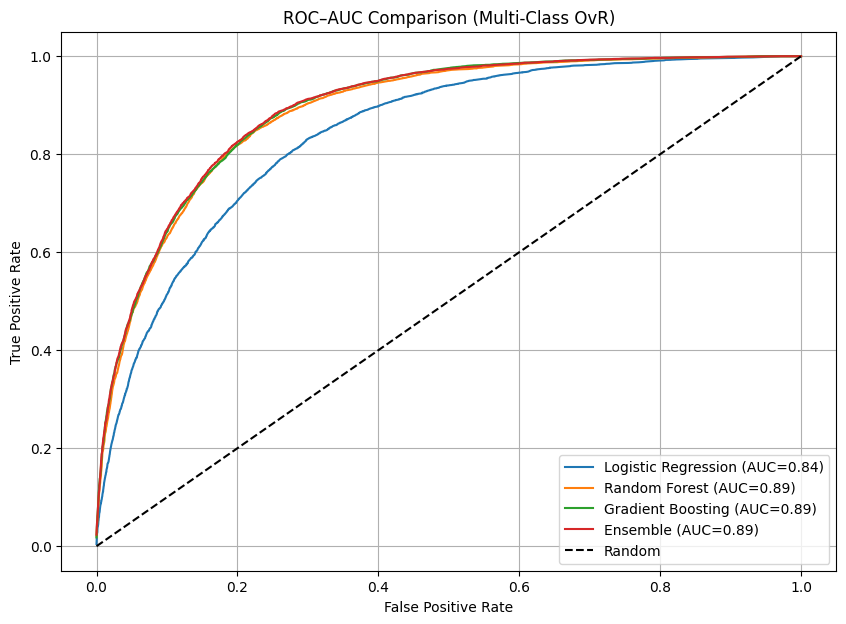

In [49]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Binarize true labels
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 7))

for name, clf in models.items():
    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_test)

        fpr = dict()
        tpr = dict()
        roc_auc = dict()

        # ROC for each class
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # Macro-average ROC
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)

        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

        mean_tpr /= n_classes
        macro_auc = auc(all_fpr, mean_tpr)

        plt.plot(all_fpr, mean_tpr, label=f"{name} (AUC={macro_auc:.2f})")

# Random guess line
plt.plot([0,1], [0,1], 'k--', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Comparison (Multi-Class OvR)")
plt.legend()
plt.grid(True)
plt.show()

